# Explore fine-tuning data

Loads the raw (`build_dataset.py`) and curated (`prepare_split.py`) `.jsonl` files for manual inspection: row composition, entity/typo detection, `crm_context`, `word_confidence`, and side-by-side transcript samples.

Set the paths below to whichever files you want to inspect -- defaults to the sample built alongside this notebook (`--max-calls 4000`, not the full corpus; see `README.md` for the full-corpus commands).

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

RAW_PATH = REPO_ROOT / "data" / "asr_dataset_sample.jsonl"
CURATED_PATH = REPO_ROOT / "data" / "asr_dataset_sample_curated.jsonl"

def load_rows(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]

raw_rows = load_rows(RAW_PATH)
curated_rows = load_rows(CURATED_PATH)
print(f"raw:     {len(raw_rows):>7,} rows  ({RAW_PATH.name})")
print(f"curated: {len(curated_rows):>7,} rows  ({CURATED_PATH.name})")

raw:      11,240 rows  (asr_dataset_sample.jsonl)
curated:  11,986 rows  (asr_dataset_sample_curated.jsonl)


## 1. Composition: raw vs. curated

`prepare_split.py` reshapes the mix a lot -- assembled (full-channel) dominance, agree-bucket upsampling, and entity upsampling all change what a random row looks like. This is the same breakdown `prepare_split.py` prints to stderr during a real run, recomputed here so you can slice it interactively.

In [2]:
def composition(rows, label):
    n = len(rows)
    n_assembled = sum(1 for r in rows if r["assembled"])
    n_chunked = n - n_assembled
    buckets = Counter(r.get("bucket") for r in rows if not r["assembled"])
    n_crm = sum(1 for r in rows if r.get("crm_context"))
    return {
        "dataset": label,
        "rows": n,
        "assembled": n_assembled,
        "assembled_frac": round(n_assembled / n, 3) if n else 0,
        "chunked": n_chunked,
        "chunked_agree_bucket": buckets.get("agree", 0),
        "rows_with_crm_context": n_crm,
    }

pd.DataFrame([composition(raw_rows, "raw"), composition(curated_rows, "curated")]).set_index("dataset")

,rows,assembled,assembled_frac,chunked,chunked_agree_bucket,rows_with_crm_context
dataset,,,,,,
raw,11240,6705,0.597,4535,519,1638
curated,11986,10806,0.902,1180,271,3271


## 2. Entity / typo detection, applied live

Reuses `prepare_split.py`'s actual detection functions (not a re-implementation) so what you see here matches exactly what a real curation run would upsample. `crm_entity_words`/`confidence_entity_words` need the corpus word-frequency table for the rarity gate -- built once, same as `prepare_split.py`'s own `main()` does.

In [3]:
from prepare_split import (
    crm_entity_words,
    confidence_entity_words,
    word_frequency,
    resample,
    downsample_to_ratio,
)

# Same defaults prepare_split.py's CLI uses (matches how the curated file was built,
# since it was run with no overrides) -- kept explicit here rather than re-parsing argv.
WER_CAP, OVERLAP_FLOOR = 1.0, 30.0
AGREE_TARGET_FRAC, ASSEMBLED_TARGET_FRAC = 0.225, 0.85
MIN_LEN, CONF_MAX, CONF_MAX_FREQ = 3, 0.3, 1

# Reconstructing entity_pool from the *curated* output isn't reliable: entity
# upsampling's --entity-max-repeats cap can downsample (not just upsample) the
# original entity-row pool, so some rows that genuinely qualified never made the
# final cut -- deduping the output file underestimates the true pool prepare_split.py
# ran its rarity check against, which was too permissive here in practice (verified:
# it roughly tripled the confidence-match count vs. rebuilding from raw). Replicating
# prepare_split.py's actual pipeline stages from the *raw* file instead, up to (but not
# including) entity upsampling itself, reproduces the exact pool it used.
import random
rng = random.Random(42)  # prepare_split.py's own default --seed

wer_ok = [r for r in raw_rows if r.get("wer_whisper") is not None and r["wer_whisper"] <= WER_CAP]
kept = [r for r in wer_ok if r.get("overlap_pct") is not None and r["overlap_pct"] >= OVERLAP_FLOOR]
chunked = [r for r in kept if not r["assembled"]]
assembled = [r for r in kept if r["assembled"]]
agree = [r for r in chunked if r.get("bucket") == "agree"]
other = [r for r in chunked if r.get("bucket") != "agree"]
agree_target = round(AGREE_TARGET_FRAC / (1 - AGREE_TARGET_FRAC) * len(other))
agree_final = resample(agree, agree_target, rng) if agree else []
chunked_before_balance = other + agree_final
assembled_final, chunked_final = downsample_to_ratio(
    assembled, chunked_before_balance, ASSEMBLED_TARGET_FRAC, rng
)

entity_pool = chunked_final + assembled_final
corpus_freq = word_frequency(entity_pool)
assembled_curated = assembled_final  # the actual pre-entity-upsampling assembled pool

crm_hits, conf_hits, both_hits = [], [], []
for r in assembled_curated:
    cw = crm_entity_words(r, MIN_LEN)
    fw = confidence_entity_words(r, MIN_LEN, CONF_MAX, corpus_freq, CONF_MAX_FREQ)
    if cw and fw:
        both_hits.append((r, cw, fw))
    elif cw:
        crm_hits.append((r, cw))
    elif fw:
        conf_hits.append((r, fw))

print(f"{len(assembled_curated)} assembled rows in the pool prepare_split.py's entity step actually saw")
print(f"  CRM-only match:        {len(crm_hits)}")
print(f"  confidence-only match: {len(conf_hits)}")
print(f"  both signals matched:  {len(both_hits)}")
print(f"  neither (no entity signal): {len(assembled_curated) - len(crm_hits) - len(conf_hits) - len(both_hits)}")

6686 assembled rows in the pool prepare_split.py's entity step actually saw
  CRM-only match:        209
  confidence-only match: 794
  both signals matched:  27
  neither (no entity signal): 5656


In [4]:
def show_row(r, highlight_words=None, width=300):
    """Prints whisper/reference side by side, wrapping highlight_words in **stars**."""
    def mark(text):
        if not highlight_words:
            return text[:width]
        out = text
        for w in highlight_words:
            out = out.replace(w, f"**{w}**")
        return out[: width + 20 * len(highlight_words)]

    print("call_id :", r.get("call_id"), "| channel:", r.get("channel"))
    print("whisper :", mark(r["text_whisper"]))
    print("ref     :", mark(r["text"]))
    if r.get("crm_context"):
        crm = r["crm_context"]
        print("customer:", crm.get("customer", {}).get("name"), "| owner:", crm.get("crm", {}).get("owner_name"))

print("=" * 30, "CRM-confirmed entity example", "=" * 30)
if crm_hits:
    r, words = crm_hits[0]
    show_row(r, highlight_words=words)

print()
print("=" * 30, "confidence-based entity example", "=" * 30)
if conf_hits:
    r, words = conf_hits[0]
    show_row(r, highlight_words=words)
    print("confidence:", {w: r["word_confidence"].get(w) for w in words})

============================== CRM-confirmed entity example ==============================
call_id : 3e8e5b47d83d6256f515c601de27134aa45e1ebfc7fb07bbaf3fc1a05e7f4b18 | channel: 0
whisper : سلام زنده باشین یه شماره تماس جدید چند لحظه بررسی کنم سفارش رو به نام خانم **فرناز** ستود سفارش جاری با همین شماره نهصد و یک بوده یه پرده داشتین چند رنگه کاتینا کاتیا متاسفانه بنده صدای شما رو ندارم اگر صدای بنده رو دارین لطفا جابجا ببشین
ref     : می‌کنم سلام زنده باشید این شماره تماس جدید چند هفته بررسی کنم سفارش رو به نام خانم **فرناز** ستوده سفارش جاری با همین شماره نهصد و یک بوده یه پرده داشتیم چند رنگ کاتینا کاتیا متاسفانه بنده صدای شما رو ندارم اگر صدای بندر رو دارین لطفا جابه‌جا بشین
customer: فرناز طاهری | owner: محدثه آرین (فرانت)

============================== confidence-based entity example ==============================
call_id : 43cef3e4f4642f03586c20861d5321921b63cb6c550d2137c8e370f62a9a85f9 | channel: 0
whisper : وقت بخیر همزلی هستم چطور می‌تونم راهنمایی‌تون کنم سلام متشکرم بفرمایید 

## 3. `word_confidence` -- Soniox's own per-word confidence

Only present on assembled rows. Sorted low-to-high so the least-confident words in a row surface first -- these are exactly the candidates the confidence-based entity detection draws from.

In [5]:
rows_with_conf = [r for r in assembled_curated if r.get("word_confidence")]
print(f"{len(rows_with_conf)}/{len(assembled_curated)} assembled rows have word_confidence data")

if rows_with_conf:
    r = rows_with_conf[0]
    lowest = sorted(r["word_confidence"].items(), key=lambda kv: kv[1])[:15]
    print("\nlowest-confidence words in one sample row:")
    for w, c in lowest:
        print(f"  {w!r:<20} {c:.3f}")

6676/6686 assembled rows have word_confidence data

lowest-confidence words in one sample row:
  'حیدرزاده'           0.510
  'سفارش\u200cتون'     0.531
  'راهنماییتون'        0.621
  'می\u200cپذیرن'      0.642
  'بله'                0.651
  'شما'                0.672
  'خدانگهدار'          0.674
  'می\u200cکنم'        0.679
  'هستم'               0.695
  'به'                 0.723
  'حیدری\u200cزاده'    0.764
  'باشین'              0.777
  'کالا'               0.777
  'کاویان'             0.782


## 4. Metric distributions

`wer_whisper`/`word_diff_pct`/`overlap_pct` are computed once in `build_dataset.py` and carried through curation -- these are the same numbers `prepare_split.py`'s `--wer-cap`/`--overlap-floor` filter against.

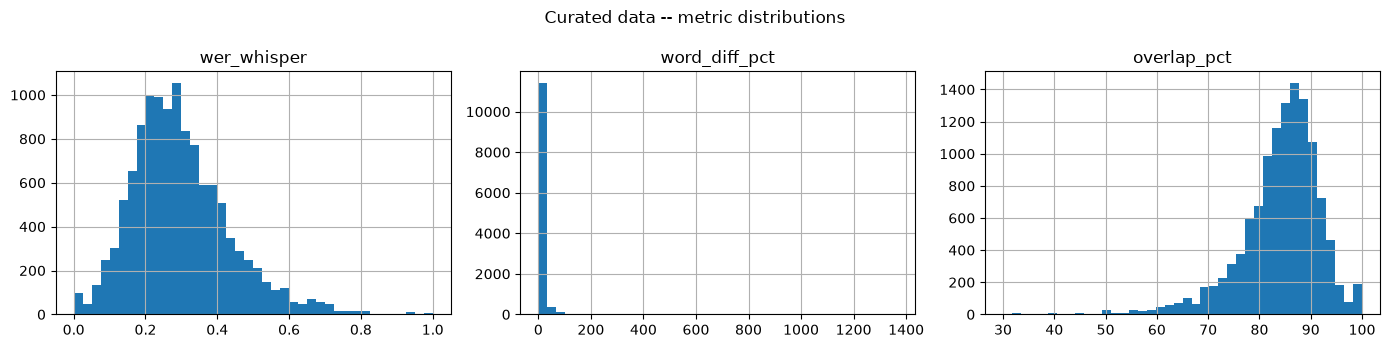

,wer_whisper,word_diff_pct,overlap_pct
count,11986.000000,11986.000000,11986.000000
mean,0.297088,10.053062,84.104116
std,0.137105,31.908568,7.912093
min,0.000000,0.000000,30.000000
25%,0.203100,2.330000,80.680000
50%,0.279700,4.890000,85.420000
75%,0.371400,9.570000,89.090000
max,1.000000,1366.670000,100.000000


In [6]:
import matplotlib.pyplot as plt

df = pd.DataFrame(curated_rows)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["wer_whisper", "word_diff_pct", "overlap_pct"]):
    df[col].dropna().hist(bins=40, ax=ax)
    ax.set_title(col)
fig.suptitle("Curated data -- metric distributions")
fig.tight_layout()
plt.show()

df[["wer_whisper", "word_diff_pct", "overlap_pct"]].describe()

## 5. Input/output length distributions

Word counts for `text_whisper` (input) and `text`/target (output), split by assembled vs. chunked -- the two are on very different scales (a full channel vs. one segment), so plotting them together would just show chunked as a spike near zero next to the assembled distribution.

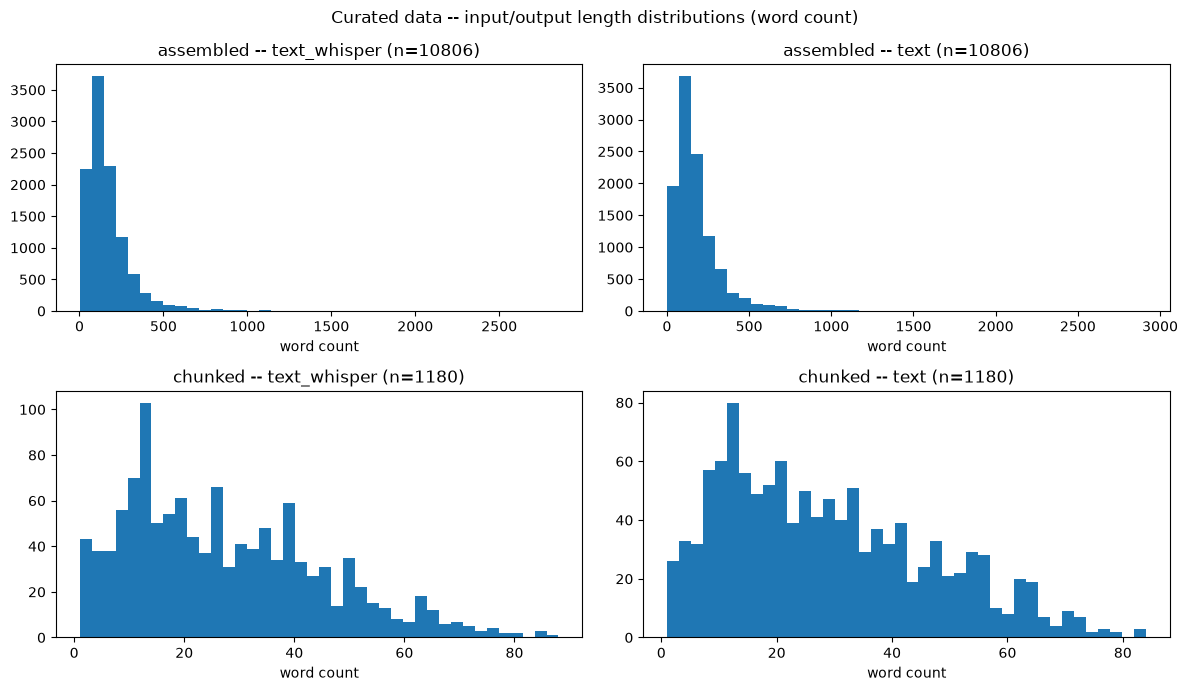

,assembled_text_whisper,assembled_text,chunked_text_whisper,chunked_text
count,10806.000000,10806.000000,1180.000000,1180.000000
mean,168.290302,179.755043,27.470339,28.921186
std,148.649670,157.747696,17.710229,17.961595
min,1.000000,1.000000,1.000000,1.000000
25%,81.000000,88.000000,13.000000,14.000000
50%,132.000000,141.000000,24.000000,25.000000
75%,207.000000,220.000000,39.000000,41.000000
max,2853.000000,2914.000000,88.000000,84.000000


In [7]:
def word_lengths(rows, col):
    return [len(r[col].split()) for r in rows]

length_groups = [
    ("assembled", [r for r in curated_rows if r["assembled"]]),
    ("chunked", [r for r in curated_rows if not r["assembled"]]),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row_idx, (label, subset) in enumerate(length_groups):
    for col_idx, col in enumerate(["text_whisper", "text"]):
        ax = axes[row_idx, col_idx]
        lengths = word_lengths(subset, col)
        ax.hist(lengths, bins=40)
        ax.set_title(f"{label} -- {col} (n={len(subset)})")
        ax.set_xlabel("word count")
fig.suptitle("Curated data -- input/output length distributions (word count)")
fig.tight_layout()
plt.show()

pd.DataFrame({
    f"{label}_{col}": pd.Series(word_lengths(subset, col))
    for label, subset in length_groups
    for col in ["text_whisper", "text"]
}).describe()

## 6. Random sample browser

Re-run this cell for a fresh random sample (no fixed seed -- this is for manual eyeballing, not a reproducible metric).

In [8]:
import random

N_SAMPLES = 5
for r in random.sample(curated_rows, min(N_SAMPLES, len(curated_rows))):
    show_row(r)
    print(f"assembled={r['assembled']} wer_whisper={r.get('wer_whisper')} bucket={r.get('bucket')}")
    print("-" * 100)

call_id : 06f91c988a70e1eb294e6d1101132d6a6208e869c6f9786264cea275c3593f3f | channel: 1
whisper : سلام خسته نباشید من یه دونه قطعات دیجی‌کالا سفارش داده بودم حالا که برام آوردم جنسش اونی که فکر می‌کردم نیست توی این زده بود چهار کیلو و نیم بعد من رفتم بیرون یا همچین چیزی دیدم جنس قوی بود این خیلی ضعیفه الان مرجوعش کردم توی این ایرادات مرجوع فراموش کردم که چند تا از ایراداتشو بنویسماونا خودشون چک 
ref     : سلام خسته نباشید من یه دونه قفس دیجیکالا سفارش داده بودم حالا که برام آوردن جنسش اونی که فکر می‌کردم نیست توی این زده بود چهار کیلو و نیم بعد من رفتم بیرون یه همچین چیزی دیدم جنس قوی بود این خیلی ضعیفه الان مرجوعش کردم فقط توی این ایرادات مرجوع فراموش کردم که چندتا از ایراداتش رو بنویسم اونا خودشون 
assembled=True wer_whisper=0.4308 bucket=None
----------------------------------------------------------------------------------------------------
call_id : 046c5d15492b7755af2ee53aee9f9c2a0a735b1babf276b698fa82a99b442e61 | channel: 1
whisper : سلام خسته نباشید خانم ما از دیجی‌کالا یه بخشی

## 7. Look up a specific call

Handy after spotting something interesting in section 5 -- pulls every row (both raw and curated, both channels if assembled) for one `call_id`, plus the full per-turn breakdown for assembled rows.

In [9]:
CALL_ID = curated_rows[0]["call_id"]  # replace with any call_id you want to inspect

print(f"=== call_id: {CALL_ID} ===\n")
for label, rows in [("raw", raw_rows), ("curated", curated_rows)]:
    matches = [r for r in rows if r["call_id"] == CALL_ID]
    print(f"--- {label}: {len(matches)} row(s) ---")
    for r in matches:
        show_row(r)
        if r.get("turns"):
            print(f"  ({len(r['turns'])} turns)")
        print()

=== call_id: 0123db805aea3e611fbaf78270afc959105e58828be14fa35770810e9bb4cc39 ===

--- raw: 2 row(s) ---
call_id : 0123db805aea3e611fbaf78270afc959105e58828be14fa35770810e9bb4cc39 | channel: 0
whisper : بخیر حادیان هستم چطور می‌تونم کمکتون کنم ببینید درخواستتون رو برای واحد شکایات ثبت کردم واحد شکایات به نوبت تماس می‌گیره به خاطر همین تا الان باهاتون تماس نگرفتن یه چند ساعت صبوری کنید لطفا حتما تماس باهاتون برقرار می‌شه بزرگتون معذرت می‌خوام ولی ببینید رویه‌اش اینه که به نوبت تماس می‌گیرن به خاطر ه
ref     : سلام وقت بخیر هادیان هستم چطور می‌تونم کمکتون کنم بله ببینین درخواستتون رو برای واحد شکایات ثبت کردم واحد شکایت به نوبت تماس می‌گیره به خاطر همین تا الان باهاتون تماس نگرفتن یه چند ساعت صبوری کنید لطفا حتما تماس باهاتون برقرار می‌شه درست من ازتون معذرت می‌خوام ولی ببینید رویه‌اش اینه که به نوبت تماس
customer: امیررضا روانستان | owner: رستا هادیان (فرانت)
  (4 turns)

call_id : 0123db805aea3e611fbaf78270afc959105e58828be14fa35770810e9bb4cc39 | channel: 1
whisper : سلام خانم من تحویل

## 8. Search for a word across the corpus

Useful for spot-checking a specific name/term you're curious about -- e.g. one flagged by the confidence-based entity detection in section 2.

In [10]:
SEARCH_WORD = "\u062d\u06cc\u062f\u0631\u06cc"  # حیدری ("Heydari") -- replace with any word

matches = [r for r in curated_rows if SEARCH_WORD in r["text"].split() or SEARCH_WORD in r["text_whisper"].split()]
print(f"{len(matches)} curated rows mention {SEARCH_WORD!r}\n")
for r in matches[:5]:
    show_row(r, highlight_words=[SEARCH_WORD])
    print()

31 curated rows mention 'حیدری'

call_id : 02fdf652e75af9c51dc695ad4109b3b96daa45e8ced6e5e65972b08385741ff2 | channel: 0
whisper : سلام وقت شما بخیر باشه بهمنش هستم چطور می‌تونم راهنماییتون کنم متشکرم بفرمایید درسته خیلی متاسفانه خانم **حیدری** بازه از بستگی داره امکانش هست برای شما نه ارسال کنه پول خیر این مورد رو انبار اعلام می‌کنه امکانش وجود نداره برای شما به این صورت تعریف می‌شه که ارسال‌های سه ساعته کوچه اول دوم سوم چهارم به این ترتیب پیش می
ref     : سلام وقت شما بخیر باشه بهمنش هستم چطور می‌تونم راهنماییتون کنم متشکرم بفرمایید درسته خیلی متاسفانه خانم **حیدری** فرصت بستگی داره امکانش هست برای شما نه ارسال کنه خیر این مورد رو انبار اعلام می‌کنه امکانش وجود نداره برای شما به این صورت طراحی می‌شه که ارسال‌های سه ساعته کوچه اول دوم سوم چهارم به این ترتیب پیش می‌ره به 
customer: رضوان شایگانی سلطان پور | owner: نسیبه بهمنش (فرانت)

call_id : 01288e9e9f0d69b90f23c91985f16866d69a5a2398383e0611ea0174e6ea390c | channel: 0
whisper : وقت بخیر ابراهیمی هستم چطور می‌تونم راهنمایی‌تون کنم مم